<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/0f/We_logo.svg/3840px-We_logo.svg.png" alt="WE Logo" width="60" style="margin-bottom:8px"/>

# Telecom Egypt (WE) — ML Project
## Smart Plan Recommendation System

---

### Background

Telecom Egypt (WE) serves thousands of subscribers across Egypt with internet plans that vary in speed, quota, and price. A key business challenge is **plan-subscriber mismatch** — subscribers enrolled in plans that do not reflect their actual usage and payment behavior.

This project simulates a real-world data science task at WE. You are part of the Data & AI team. Your mission is to build a machine learning model that analyzes subscriber profiles and recommends the most suitable plan action:

> **Upgrade** — the subscriber needs a bigger plan  
> **Downgrade** — the subscriber is over-paying for what they use  
> **Keep** — the current plan is a good fit

---

### Available Datasets

| Dataset | Description |
|---------|-------------|
| `Customer.csv` | Subscriber demographics and plan enrollment |
| `Subscription_Plan_Lkp.csv` | Plan details — quota, speed, and price |
| `Network_Elements.csv` | Infrastructure type per subscriber (VDSL, FTTH, etc.) |
| `Payments.csv` | Monthly payment transactions per subscriber |
| `Consumption_RG_LKP.csv` | Lookup table for consumption rating groups |

---

### General Instructions

- Read each step carefully before writing any code.
- Each step has a clear objective — understand **why** you are doing it, not just **how**.
- You are expected to make decisions along the way. Document your reasoning in markdown cells.
- There is no single correct answer — justify your choices.


---
## Step 1 — Load & Explore the Data

### Objective
Understand what data you have before touching it.

### Why This Step Matters
Before building any model, a data scientist must fully understand the data — its structure, quality, and distributions. Skipping EDA leads to wrong assumptions and poor models.

### What To Do
- Load all 5 datasets and print their shape and data types.
- Check for missing values in each table and decide how to handle them.
- Visualize key distributions:
  - `Customer`: `SUBSCRIBER_STATUS`, `CUSTOMER_CLASS`, `GENDER`
  - `Subscription_Plan_Lkp`: price range, speed range, quota sizes
  - `Payments`: revenue columns and monthly revenue trend
  - `Network_Elements`: breakdown of `TECHNOLOGY_TYPE`

**Expected Output:** At least 4 visualizations. Write a short observation below each one explaining what you see.


In [21]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#In this step, we load the datasets and explore their structure before building any machine learning model.

In [22]:
# ── Load Data ────────────────────────────────────────────────────────────────
#the datasets are loaded into pandas dataframes
customer = pd.read_csv("Customer.csv")
plans = pd.read_csv("Subscription_Plan_Lkp.csv")
network = pd.read_csv("Network_Elements.csv")
payments = pd.read_csv("Payments.csv")
consumption = pd.read_csv("Consumption_RG_LKP.csv")
#The shape of each dataset shows the number of rows and columns
print(customer.shape)
print(plans.shape)
print(network.shape)
print(payments.shape)
print(consumption.shape)
#Checking the data types helps us identify numerical and categorical features
customer.info()
plans.info()
network.info()
payments.info()
consumption.info()


(9995, 17)
(108, 11)
(9918, 8)
(362713, 10)
(20, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9995 entries, 0 to 9994
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SUBSCRIBER_ID#                9995 non-null   int64  
 1   ACCOUNT_ID#                   9995 non-null   int64  
 2   CUSTOMER_ID#                  9995 non-null   int64  
 3   GROUP_ID#                     675 non-null    float64
 4   NAME                          9995 non-null   object 
 5   SUBSCRIBER_STATUS             9995 non-null   object 
 6   STATUS_DATE                   9995 non-null   object 
 7   GENDER                        9995 non-null   object 
 8   BIRTHDATE                     9934 non-null   object 
 9   ID_TYPE                       9995 non-null   object 
 10  NATIONALITY                   9995 non-null   object 
 11  ACTIVATION_DATE               9995 non-null   object 
 12  CUSTOMER_C

In [23]:
#missing values
print("Customer")
print(customer.isnull().sum())

print("\nPlans")
print(plans.isnull().sum())

print("\nNetwork")
print(network.isnull().sum())

print("\nPayments")
print(payments.isnull().sum())

print("\nConsumption")
print(consumption.isnull().sum())

Customer
SUBSCRIBER_ID#                     0
ACCOUNT_ID#                        0
CUSTOMER_ID#                       0
GROUP_ID#                       9320
NAME                               0
SUBSCRIBER_STATUS                  0
STATUS_DATE                        0
GENDER                             0
BIRTHDATE                         61
ID_TYPE                            0
NATIONALITY                        0
ACTIVATION_DATE                    0
CUSTOMER_CLASS                     0
SUBSCRIBER_TYPE                    0
SUBSCRIPTION_PLAN_FAMILY_ID#       0
SUBSCRIPTION_PLAN_ID#              0
SERVICE_NUMBER#                    0
dtype: int64

Plans
SUBSCRIPTION_PLAN_ID#                  0
SUBSCRIPTION_PLAN_FAMILY_ID#           0
SUBSCRIPTION_PLAN_DESC                 0
SUBSCRIPTION_PLAN_FAMILY_DESC          0
QUOTA                                  0
SPEED                                  0
PRICE_PLAN_PRICE                       0
SUBSCRIPTION_PLAN_START_TIME           0
SUBSCRIPTION_P

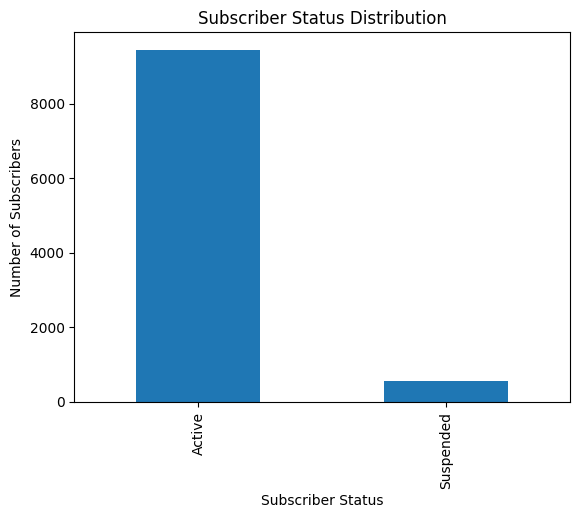

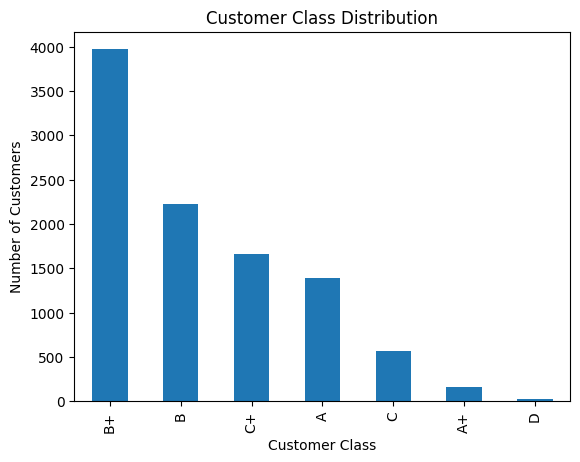

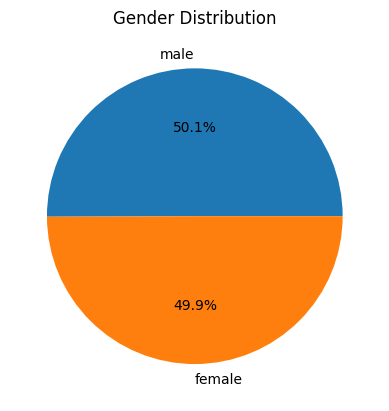

In [24]:
# ── EDA: Customer Table ──────────────────────────────────────────────────────
customer["SUBSCRIBER_STATUS"].value_counts().plot(kind="bar")

plt.title("Subscriber Status Distribution")
plt.xlabel("Subscriber Status")
plt.ylabel("Number of Subscribers")
plt.show()
#Most subscribers are Active, while only a small number belong to other subscription statuses
customer["CUSTOMER_CLASS"].value_counts().plot(kind="bar")

plt.title("Customer Class Distribution")
plt.xlabel("Customer Class")
plt.ylabel("Number of Customers")
plt.show()

customer["GENDER"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()




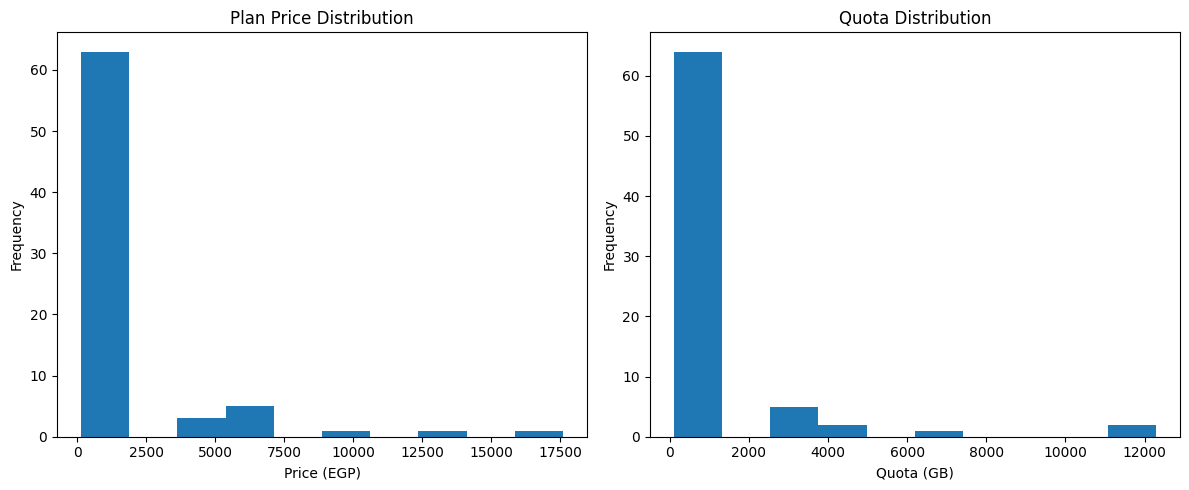

In [25]:
#EDA: plans table--------------------------------------------------

# Filter active plans
active_plans = plans[plans["PRICE_PLAN_PRICE"] > 0].copy()

# Convert QUOTA to numeric
active_plans["QUOTA"] = active_plans["QUOTA"].replace("1TB", "1024")
active_plans["QUOTA"] = active_plans["QUOTA"].astype(float)

# Create two plots side by side
plt.figure(figsize=(12,5))

# Price Plot
plt.subplot(1,2,1)
active_plans["PRICE_PLAN_PRICE"].plot(kind="hist", bins=10)
plt.title("Plan Price Distribution")
plt.xlabel("Price (EGP)")
plt.ylabel("Frequency")

# Quota Plot
plt.subplot(1,2,2)
active_plans["QUOTA"].plot(kind="hist", bins=10)
plt.title("Quota Distribution")
plt.xlabel("Quota (GB)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

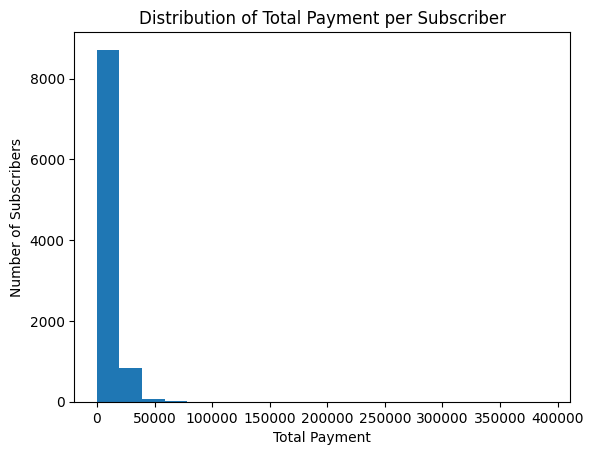

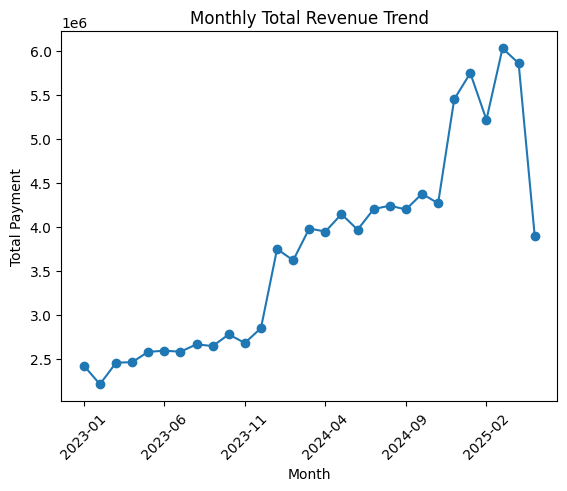

In [26]:
# ── EDA: Payments Table ──────────────────────────────────────────────────────
payments["total_payment"] = (
    payments["RENT_REVENUE"] +
    payments["OUT_BUNDLE_REVENUE"] +
    payments["CREATION_FEES_REVENUE"] +
    payments["DEVICES_REVENUE"] +
    payments["IN_BUNDLE_REVENUE"] +
    payments["ADDON_REVENUE"] +
    payments["TAX_AMOUNT"]
)
subscriber_payment = payments.groupby("SUBSCRIBER_ID#")["total_payment"].sum()

subscriber_payment.plot(kind="hist", bins=20)

plt.title("Distribution of Total Payment per Subscriber")
plt.xlabel("Total Payment")
plt.ylabel("Number of Subscribers")
plt.show()
payments["CONNECT_DATE"] = pd.to_datetime(payments["CONNECT_DATE"])

monthly_payment = payments.groupby(
    payments["CONNECT_DATE"].dt.to_period("M")
)["total_payment"].sum()

monthly_payment.index = monthly_payment.index.astype(str)

monthly_payment.plot(kind="line", marker="o")

plt.title("Monthly Total Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Payment")
plt.xticks(rotation=45)

plt.show()


---
## Step 2 — Join the Tables

### Objective
Build a single unified subscriber profile by merging all relevant tables.

### Why This Step Matters
Real-world data is never in one place. The ability to correctly join tables — using the right keys and avoiding duplicates or row explosions — is a core data engineering skill.

### What To Do
- Start from `Customer.csv` as the base table.
- Join `Subscription_Plan_Lkp` on `SUBSCRIPTION_PLAN_ID#` → adds quota, speed, price.
- Join `Network_Elements` on `SERVICE_NUMBER#` → adds technology type.
- Aggregate `Payments` per subscriber, then join on `SUBSCRIBER_ID#`.
- After each join, verify the row count has not changed unexpectedly.

> **Watch out for:** Duplicate plan IDs in the lookup table — handle them before joining to avoid inflating your row count.


In [27]:
# ── Clean Plans ───────────────────────────────────


In [28]:
# ── Join Plans ────────────────────────────────────────────────────────────────

In [29]:
# ── Join Network ──────────────────────────────────────────────────────────────

In [30]:
# ── Aggregate Payments ────────────────────────────────────────────────────────

---
## Step 3 — Feature Engineering

### Objective
Transform raw columns into meaningful features that help the model learn patterns.

### Why This Step Matters
Raw data rarely goes directly into a model. Feature engineering is where domain knowledge meets data science — the better your features, the better your model.

### Features To Create

| Feature | Formula | What It Captures |
|---------|---------|-----------------|
| `tenure_days` | `reference_date − ACTIVATION_DATE` | How long the subscriber has been active |
| `avg_monthly_rev` | Mean of payments per subscriber | Average spending per month |
| `addon_ratio` | `addon_total / total_revenue` | How often the subscriber exceeds their bundle |
| `price_to_quota_ratio` | `PRICE_PLAN_PRICE / QUOTA_NUM` | Cost per GB — how expensive the plan is relative to its size |

---

**Formula Details:**

**addon_ratio:**

$$\text{addon_ratio} = \frac{\text{ADDON_REVENUE}}{\text{total_revenue}}$$

*Example:* Subscriber paid 500 EGP total, 100 EGP was addon → addon_ratio = 100/500 = **0.20** (20% outside bundle)

---

**price_to_quota_ratio:**

$$\text{price_to_quota_ratio} = \frac{\text{PRICE_PLAN_PRICE}}{\text{QUOTA_NUM}}$$

*Example:* Plan costs 570 EGP for 400 GB → price_to_quota_ratio = 570/400 = **1.43 EGP per GB**

---

After creating each feature, print a `.describe()` and check for outliers or unexpected values.


In [31]:
# ── tenure_days ──────────────────────────────────────────────────────────────

In [32]:
# ── addon_ratio ──────────────────────────────────────────────────────────────
# addon_ratio = addon_total / total_revenue


In [33]:
# ── price_to_quota_ratio ─────────────────────────────────────────────────────
# price_to_quota_ratio = PRICE_PLAN_PRICE / QUOTA_NUM (EGP per GB)


In [34]:
# ── Summary: All Engineered Features ─────────────────────────────────────────


---
## Step 4 — Build the Target Variable

### Objective
Define the label the model will learn to predict.

### Why This Step Matters
In supervised ML, the quality of your label directly determines the quality of your model. Here, there is no pre-labeled column — you must define the business logic yourself.

### Labeling Logic

First, compute the **pay_ratio** — how much the subscriber actually pays relative to their plan price:

$$\text{pay_ratio} = \frac{\text{avg_monthly_rev}}{\text{PRICE_PLAN_PRICE}}$$

Then apply the following rules:

| Condition | Label |
|-----------|-------|
| `addon_ratio > 0.15` OR `pay_ratio > 1.30` | `Upgrade` — paying beyond their plan |
| `pay_ratio < 0.50` | `Downgrade` — consistently under-paying |
| Everything else | `Keep` — plan is a good fit |

**Examples:**

| Subscriber | Plan Price | Avg Monthly Pay | pay_ratio | addon_ratio | Label |
|-----------|-----------|----------------|-----------|-------------|-------|
| A | 400 EGP | 550 EGP | 1.375 → 137% | 0.05 | **Upgrade** |
| B | 400 EGP | 180 EGP | 0.450 → 45% | 0.01 | **Downgrade** |
| C | 400 EGP | 350 EGP | 0.875 → 87% | 0.08 | **Keep** |


---

After labeling: print the class distribution. If any class has fewer than 5% of records, discuss in a markdown cell whether this is a problem and how you would handle it.


In [35]:
# ── Compute pay_ratio ────────────────────────────────────────────────────────

In [36]:
# ── Class Distribution ────────────────────────────────────────────────────────

---
## Step 5 — Train & Compare Models

### Objective
Train multiple classifiers and understand the tradeoffs between them.

### Why This Step Matters
No single model is always best. A good data scientist knows when to use a simple interpretable model versus a complex one — and can justify that choice to a non-technical business stakeholder.

### Models To Train

| Model | Why |
|-------|-----|
| **Logistic Regression** | Your baseline — fast, interpretable, good for linear relationships |
| **Random Forest** | Handles non-linearity and feature interactions well |
| **Gradient Boosting** | Typically stronger performance but slower to train |

### Rules
- Use the same train/test/val split for all models `random_state=42`
- Print the Classification Report for each model
- Note any class where the model performs poorly and explain why in a markdown cell


In [37]:
# ── Select Features & Filter ─────────────────────────────────────────────────


In [38]:
# ── Handle Missing Values ─────────────────────────────────────────────────────

In [39]:
# ── Encode Categorical Features ──────────────────────────────────────────────

In [40]:
# ── Train / Test Split ───────────────────────────────────────────────────────

In [41]:
# ── Model 1: Logistic Regression (Baseline) ──────────────────────────────────

In [42]:
# ── Model 2: Random Forest ───────────────────────────────────────────────────

In [43]:
# ── Model 3: Gradient Boosting ───────────────────────────────────────────────

---
## Step 6 — Evaluate

### Objective
Measure model performance beyond just accuracy.


In [44]:
# ── Model Comparison ─────────────────────────────────────────────────────────


In [45]:
# ── Confusion Matrix (Best Model) ────────────────────────────────────────────


---
## Step 7 — Business Impact

### Objective
Translate model predictions into actionable business recommendations.



In [46]:
# ── Predictions on Full Dataset ──────────────────────────────────────────────

In [47]:
# ── Revenue Opportunity ──────────────────────────────────────────────────────


In [48]:
# ── Upgrade Candidates Profile ───────────────────────────────────────────────
